In [4]:
# Phase-pure Fe3O4 XRD data generator:
# (1) size series: 5 to 20 nm, 10 samples
# (2) shifted-peak series: -0.05 to 0.05 deg 2theta, 10 samples
#
# Keeps a fixed 2theta grid for all samples.

import json
import numpy as np
import matplotlib.pyplot as plt

from pymatgen.core import Structure, Lattice
from pymatgen.analysis.diffraction.xrd import XRDCalculator


# plots

FONTSIZE = 16


# ------------------------------------------------------------
# Load Fe3O4 CIF
# ------------------------------------------------------------
fe3o4_struct = Structure.from_file("1010369_Fe3O4.cif")

# ------------------------------------------------------------
# Helper: make cubic Fe3O4 structure with modified lattice parameter
# ------------------------------------------------------------
def make_cubic_structure_with_lattice_parameter(struct, a_A):
    """
    Creates a copy of the input structure with a new cubic lattice parameter.

    Works for both ordered and partially occupied/disordered CIFs because it
    preserves each site's species/occupancy object using site.species.
    """
    new_lattice = Lattice.cubic(a_A)

    site_species = [site.species for site in struct.sites]
    frac_coords = [site.frac_coords for site in struct.sites]

    return Structure(
        lattice=new_lattice,
        species=site_species,
        coords=frac_coords,
        coords_are_cartesian=False,
        site_properties=struct.site_properties
    )

# ------------------------------------------------------------
# Phase-pure Fe3O4 simulator with optional rigid peak shift
# and optional modified cubic lattice parameter
# ------------------------------------------------------------
def simulate_xrd_fe3o4_pure(
    grain_size_nm,
    peak_shift_deg=0.0,
    lattice_parameter_A=None,
    two_theta_range=(25, 65),
    num_points=2000,
    K=0.9,
    wavelength=1.54184,
    instr_fwhm_deg=0.02,
    eta=0.3
):
    calc = XRDCalculator(wavelength="CuKa")

    # Fixed 2theta grid for all samples
    two_theta = np.linspace(two_theta_range[0], two_theta_range[1], num_points)
    intensity = np.zeros_like(two_theta)

    # Choose structure: original CIF or modified cubic lattice parameter
    if lattice_parameter_A is None:
        xrd_struct = fe3o4_struct
    else:
        xrd_struct = make_cubic_structure_with_lattice_parameter(
            fe3o4_struct,
            lattice_parameter_A
        )

    # Get stick pattern from structure
    pat = calc.get_pattern(xrd_struct, two_theta_range=two_theta_range)

    # Convert grain size nm -> Å
    D_A = grain_size_nm * 10.0

    for x0, I0 in zip(pat.x, pat.y):
        # Optional rigid peak shift while preserving fixed grid
        # If lattice_parameter_A is changed, x0 has already moved physically.
        x_center = x0 + peak_shift_deg

        theta0 = np.radians(x_center / 2.0)

        # Scherrer broadening
        beta_size_rad = (K * wavelength) / (D_A * np.cos(theta0))
        beta_size_deg = beta_size_rad * 180.0 / np.pi

        # Total FWHM in degrees
        beta_total = np.sqrt(beta_size_deg**2 + instr_fwhm_deg**2)

        # Pseudo-Voigt components
        sigma_G = beta_total / (2.0 * np.sqrt(2.0 * np.log(2.0)))
        gamma_L = beta_total / 2.0

        diff = two_theta - x_center
        G = np.exp(-(diff**2) / (2.0 * sigma_G**2)) / (sigma_G * np.sqrt(2.0 * np.pi))
        L = (1.0 / np.pi) * (gamma_L / (diff**2 + gamma_L**2))

        intensity += I0 * (eta * L + (1.0 - eta) * G)

    # Normalize
    if intensity.max() > 0:
        intensity = intensity / intensity.max()

    return two_theta, intensity

# ------------------------------------------------------------
# Generate datasets
# ------------------------------------------------------------
N_size = 10
N_shift = 10
N_lattice = 10

# Set 1: phase-pure Fe3O4, size series from 5 to 20 nm
size_values_nm = np.linspace(10.0, 15.0, N_size)

# Set 2: phase-pure Fe3O4, shifted peaks from -0.244 to 0.244 deg
shift_values_deg = np.linspace(-0.244, 0.244, N_shift)
shift_values_deg[np.argmin(np.abs(shift_values_deg))] = 0.0

# Set 3: phase-pure Fe3O4, modified cubic lattice parameter
lattice_values_A = np.linspace(8.345, 8.395, N_lattice)

# Choose a fixed size for the shift test
fixed_shift_size_nm = 14.0

# Choose a fixed size for the lattice-parameter test
fixed_lattice_size_nm = 14.0

# Fixed grid from first simulation
two_theta_grid, _ = simulate_xrd_fe3o4_pure(
    grain_size_nm=size_values_nm[0],
    peak_shift_deg=0.0
)
n_xrd = len(two_theta_grid)

# Storage

xrd_size_series = np.zeros((N_size, n_xrd), dtype=np.float32)
xrd_shift_series = np.zeros((N_shift, n_xrd), dtype=np.float32)
xrd_lattice_series = np.zeros((N_lattice, n_xrd), dtype=np.float32)

# Labels
labels_size = []
labels_shift = []
labels_lattice = []

# Generate size series
for i, d_nm in enumerate(size_values_nm):
    _, I = simulate_xrd_fe3o4_pure(
        grain_size_nm=d_nm,
        peak_shift_deg=0.0
    )
    xrd_size_series[i, :] = I
    labels_size.append({
        "id": int(i),
        "grain_size_nm": float(d_nm),
        "peak_shift_deg": 0.0,
        "phase": "Fe3O4"
    })

# Generate shift series
for i, shift_deg in enumerate(shift_values_deg):
    _, I = simulate_xrd_fe3o4_pure(
        grain_size_nm=fixed_shift_size_nm,
        peak_shift_deg=shift_deg
    )
    xrd_shift_series[i, :] = I
    labels_shift.append({
        "id": int(i),
        "grain_size_nm": float(fixed_shift_size_nm),
        "peak_shift_deg": float(shift_deg),
        "phase": "Fe3O4"
    })

# Generate lattice-parameter series
for i, a_A in enumerate(lattice_values_A):
    _, I = simulate_xrd_fe3o4_pure(
        grain_size_nm=fixed_lattice_size_nm,
        peak_shift_deg=0.0,
        lattice_parameter_A=a_A
    )
    xrd_lattice_series[i, :] = I
    labels_lattice.append({
        "id": int(i),
        "grain_size_nm": float(fixed_lattice_size_nm),
        "peak_shift_deg": 0.0,
        "lattice_parameter_A": float(a_A),
        "phase": "Fe3O4"
    })

# ------------------------------------------------------------
# Save as NPZ
# ------------------------------------------------------------
np.savez(
    "fe3o4_basic_size_shift_lattice_sets_new_range.npz",
    two_theta=two_theta_grid,
    xrd_size_series=xrd_size_series,
    xrd_shift_series=xrd_shift_series,
    xrd_lattice_series=xrd_lattice_series,
    size_values_nm=size_values_nm,
    shift_values_deg=shift_values_deg,
    lattice_values_A=lattice_values_A,
    fixed_shift_size_nm=fixed_shift_size_nm,
    fixed_lattice_size_nm=fixed_lattice_size_nm
)

print("Saved fe3o4_basic_size_shift_lattice_sets_new_range.npz")

payload = {
    "two_theta": two_theta_grid.tolist(),
    "size_series": [
        {
            "metadata": labels_size[i],
            "xrd": xrd_size_series[i].tolist()
        }
        for i in range(N_size)
    ],
    "shift_series": [
        {
            "metadata": labels_shift[i],
            "xrd": xrd_shift_series[i].tolist()
        }
        for i in range(N_shift)
    ],
    "lattice_series": [
        {
            "metadata": labels_lattice[i],
            "xrd": xrd_lattice_series[i].tolist()
        }
        for i in range(N_lattice)
    ]
}

with open("fe3o4_basic_size_shift_lattice_sets_new_range.json", "w", encoding="utf-8") as f:
    json.dump(payload, f, indent=2)

print("Saved fe3o4_basic_size_shift_lattice_sets.json")



Saved fe3o4_basic_size_shift_lattice_sets_new_range.npz
Saved fe3o4_basic_size_shift_lattice_sets.json


In [5]:
print(fe3o4_struct.lattice)
print("abc:", fe3o4_struct.lattice.abc)
print("angles:", fe3o4_struct.lattice.angles)

8.384000 0.000000 0.000000
0.000000 8.384000 0.000000
0.000000 0.000000 8.384000
abc: (8.384, 8.384, 8.384)
angles: (90.0, 90.0, 90.0)


In [11]:
# Phase-pure Fe3O4 XRD data generator:
# (1) size series: 5 to 20 nm, 10 samples
# (2) shifted-peak series: -0.05 to 0.05 deg 2theta, 10 samples
#
# Keeps a fixed 2theta grid for all samples.

import json
import numpy as np
import matplotlib.pyplot as plt

from pymatgen.core import Structure, Lattice
from pymatgen.analysis.diffraction.xrd import XRDCalculator


# plots

FONTSIZE = 16


# ------------------------------------------------------------
# Load Fe3O4 CIF
# ------------------------------------------------------------
fe3o4_struct = Structure.from_file("1010369_Fe3O4.cif")

# ------------------------------------------------------------
# Helper: make cubic Fe3O4 structure with modified lattice parameter
# ------------------------------------------------------------
def make_cubic_structure_with_lattice_parameter(struct, a_A):
    """
    Creates a copy of the input structure with a new cubic lattice parameter.

    Works for both ordered and partially occupied/disordered CIFs because it
    preserves each site's species/occupancy object using site.species.
    """
    new_lattice = Lattice.cubic(a_A)

    site_species = [site.species for site in struct.sites]
    frac_coords = [site.frac_coords for site in struct.sites]

    return Structure(
        lattice=new_lattice,
        species=site_species,
        coords=frac_coords,
        coords_are_cartesian=False,
        site_properties=struct.site_properties
    )

# ------------------------------------------------------------
# Phase-pure Fe3O4 simulator with optional rigid peak shift
# and optional modified cubic lattice parameter
# ------------------------------------------------------------
def simulate_xrd_fe3o4_pure(
    grain_size_nm,
    peak_shift_deg=0.0,
    lattice_parameter_A=None,
    two_theta_range=(25, 65),
    num_points=2000,
    K=0.9,
    wavelength=1.54184,
    instr_fwhm_deg=0.02,
    eta=0.3
):
    calc = XRDCalculator(wavelength="CuKa")

    # Fixed 2theta grid for all samples
    two_theta = np.linspace(two_theta_range[0], two_theta_range[1], num_points)
    intensity = np.zeros_like(two_theta)

    # Choose structure: original CIF or modified cubic lattice parameter
    if lattice_parameter_A is None:
        xrd_struct = fe3o4_struct
    else:
        xrd_struct = make_cubic_structure_with_lattice_parameter(
            fe3o4_struct,
            lattice_parameter_A
        )

    # Get stick pattern from structure
    pat = calc.get_pattern(xrd_struct, two_theta_range=two_theta_range)

    # Convert grain size nm -> Å
    D_A = grain_size_nm * 10.0

    for x0, I0 in zip(pat.x, pat.y):
        # Optional rigid peak shift while preserving fixed grid
        # If lattice_parameter_A is changed, x0 has already moved physically.

        x_center = x0 + peak_shift_deg
        theta0 = np.radians(x0 / 2.0)

        # Scherrer broadening
        beta_size_rad = (K * wavelength) / (D_A * np.cos(theta0))
        beta_size_deg = beta_size_rad * 180.0 / np.pi

        # Total FWHM in degrees
        beta_total = np.sqrt(beta_size_deg**2 + instr_fwhm_deg**2)

        # Pseudo-Voigt components
        sigma_G = beta_total / (2.0 * np.sqrt(2.0 * np.log(2.0)))
        gamma_L = beta_total / 2.0

        diff = two_theta - x_center
        G = np.exp(-(diff**2) / (2.0 * sigma_G**2)) / (sigma_G * np.sqrt(2.0 * np.pi))
        L = (1.0 / np.pi) * (gamma_L / (diff**2 + gamma_L**2))

        intensity += I0 * (eta * L + (1.0 - eta) * G)

    # Normalize
    if intensity.max() > 0:
        intensity = intensity / intensity.max()

    return two_theta, intensity

# ------------------------------------------------------------
# Generate datasets
# ------------------------------------------------------------
N_size = 10
N_shift = 10
N_lattice = 10

# Set 1: phase-pure Fe3O4, size series from 5 to 20 nm
size_values_nm = np.linspace(10.0, 15.0, N_size)

# Set 2: phase-pure Fe3O4, shifted peaks from -0.244 to 0.244 deg
shift_values_deg = np.linspace(-0.244, 0.244, N_shift)
shift_values_deg[np.argmin(np.abs(shift_values_deg))] = 0.0

# Set 3: phase-pure Fe3O4, modified cubic lattice parameter
lattice_values_A = np.linspace(8.345, 8.395, N_lattice)

# Choose a fixed size for the shift test
fixed_shift_size_nm = 14.0

# Choose a fixed size for the lattice-parameter test
fixed_lattice_size_nm = 14.0

# Fixed grid from first simulation
two_theta_grid, _ = simulate_xrd_fe3o4_pure(
    grain_size_nm=size_values_nm[0],
    peak_shift_deg=0.0
)
n_xrd = len(two_theta_grid)

# Storage

xrd_size_series = np.zeros((N_size, n_xrd), dtype=np.float32)
xrd_shift_series = np.zeros((N_shift, n_xrd), dtype=np.float32)
xrd_lattice_series = np.zeros((N_lattice, n_xrd), dtype=np.float32)

# Labels
labels_size = []
labels_shift = []
labels_lattice = []

# Generate size series
for i, d_nm in enumerate(size_values_nm):
    _, I = simulate_xrd_fe3o4_pure(
        grain_size_nm=d_nm,
        peak_shift_deg=0.0
    )
    xrd_size_series[i, :] = I
    labels_size.append({
        "id": int(i),
        "grain_size_nm": float(d_nm),
        "peak_shift_deg": 0.0,
        "phase": "Fe3O4"
    })

# Generate shift series
for i, shift_deg in enumerate(shift_values_deg):
    _, I = simulate_xrd_fe3o4_pure(
        grain_size_nm=fixed_shift_size_nm,
        peak_shift_deg=shift_deg
    )
    xrd_shift_series[i, :] = I
    labels_shift.append({
        "id": int(i),
        "grain_size_nm": float(fixed_shift_size_nm),
        "peak_shift_deg": float(shift_deg),
        "phase": "Fe3O4"
    })

# Generate lattice-parameter series
for i, a_A in enumerate(lattice_values_A):
    _, I = simulate_xrd_fe3o4_pure(
        grain_size_nm=fixed_lattice_size_nm,
        peak_shift_deg=0.0,
        lattice_parameter_A=a_A
    )
    xrd_lattice_series[i, :] = I
    labels_lattice.append({
        "id": int(i),
        "grain_size_nm": float(fixed_lattice_size_nm),
        "peak_shift_deg": 0.0,
        "lattice_parameter_A": float(a_A),
        "phase": "Fe3O4"
    })

# ------------------------------------------------------------
# Save as NPZ
# ------------------------------------------------------------
np.savez(
    "fe3o4_basic_size_shift_lattice_2theta_shift_fix.npz",
    two_theta=two_theta_grid,
    xrd_size_series=xrd_size_series,
    xrd_shift_series=xrd_shift_series,
    xrd_lattice_series=xrd_lattice_series,
    size_values_nm=size_values_nm,
    shift_values_deg=shift_values_deg,
    lattice_values_A=lattice_values_A,
    fixed_shift_size_nm=fixed_shift_size_nm,
    fixed_lattice_size_nm=fixed_lattice_size_nm
)

print("Saved fe3o4_basic_size_shift_lattice_2theta_shift_fix.npz")

payload = {
    "two_theta": two_theta_grid.tolist(),
    "size_series": [
        {
            "metadata": labels_size[i],
            "xrd": xrd_size_series[i].tolist()
        }
        for i in range(N_size)
    ],
    "shift_series": [
        {
            "metadata": labels_shift[i],
            "xrd": xrd_shift_series[i].tolist()
        }
        for i in range(N_shift)
    ],
    "lattice_series": [
        {
            "metadata": labels_lattice[i],
            "xrd": xrd_lattice_series[i].tolist()
        }
        for i in range(N_lattice)
    ]
}

with open("fe3o4_basic_size_shift_lattice_sets_2theta_shift_fix.json", "w", encoding="utf-8") as f:
    json.dump(payload, f, indent=2)

print("Saved fe3o4_basic_size_shift_lattice_sets.json")



Saved fe3o4_basic_size_shift_lattice_2theta_shift_fix.npz
Saved fe3o4_basic_size_shift_lattice_sets.json


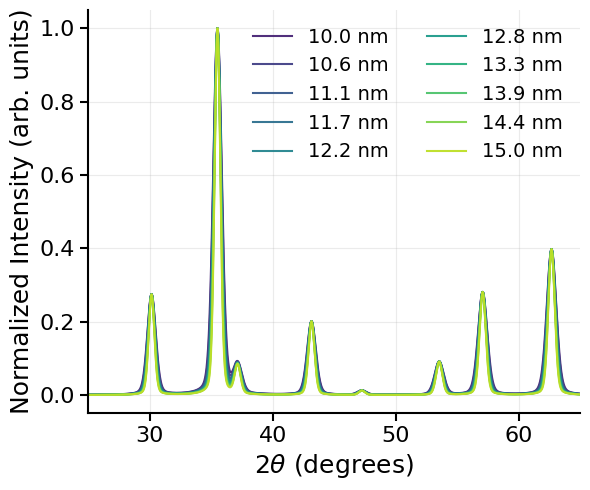

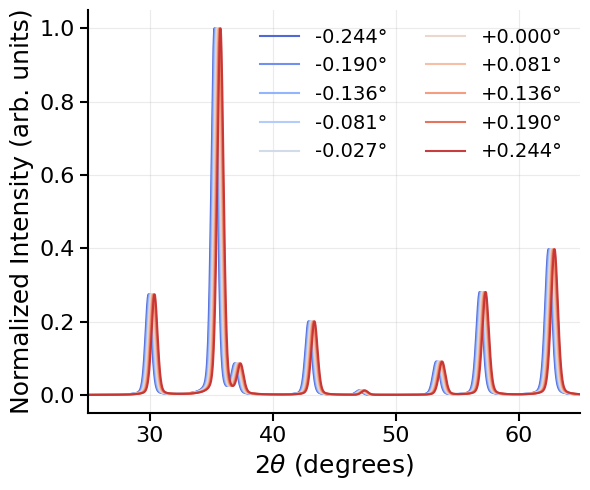

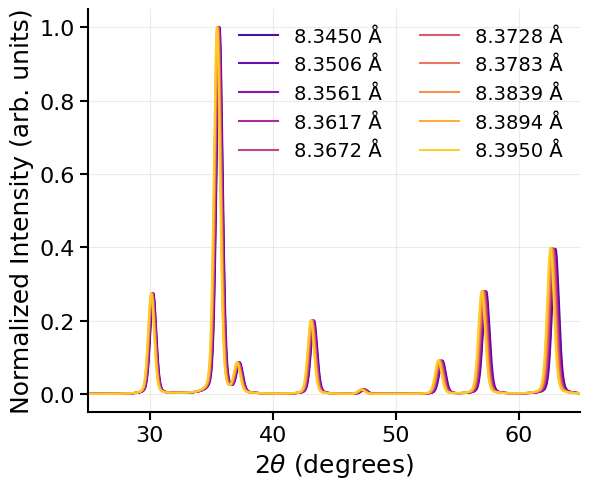

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# =========================
# Load simulated XRD dataset
# =========================

data = np.load(
    r"C:\Users\fabel\Documents\materials-project\notesbooks\Iron_Oxide_Model\fe3o4_basic_size_shift_lattice_2theta_shift_fix.npz"
)

two_theta_grid = data["two_theta"]

xrd_size_series = data["xrd_size_series"]
xrd_shift_series = data["xrd_shift_series"]
xrd_lattice_series = data["xrd_lattice_series"]

size_values_nm = data["size_values_nm"]
shift_values_deg = data["shift_values_deg"]
lattice_values_A = data["lattice_values_A"]

N_size = len(size_values_nm)
N_shift = len(shift_values_deg)
N_lattice = len(lattice_values_A)

# =========================
# Plot styling
# =========================
FONTSIZE = 18
TICK_FONTSIZE = 16
LEGEND_FONTSIZE = 14
LINEWIDTH = 1.5

def style_xrd_axis(ax):
    ax.set_xlim(25, 65)
    ax.set_xlabel(r"2$\theta$ (degrees)", fontsize=FONTSIZE)
    ax.set_ylabel("Normalized Intensity (arb. units)", fontsize=FONTSIZE)

    ax.tick_params(axis="both", labelsize=TICK_FONTSIZE, width=1.5, length=6)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.5)
    ax.spines["bottom"].set_linewidth(1.5)

    ax.grid(alpha=0.25, linewidth=0.8)


# =========================
# Plot 1: crystallite-size series
# =========================
fig, ax = plt.subplots(figsize=(6, 5))

colors = plt.cm.viridis(np.linspace(0.1, 0.9, N_size))

for i in range(N_size):
    ax.plot(
        two_theta_grid,
        xrd_size_series[i],
        color=colors[i],
        lw=LINEWIDTH,
        alpha=0.95,
        label=f"{size_values_nm[i]:.1f} nm"
    )

style_xrd_axis(ax)

ax.legend(
    fontsize=LEGEND_FONTSIZE,
    ncol=2,
    frameon=False,
    handlelength=2.0
)

fig.tight_layout()
plt.show()


# =========================
# Plot 2: rigid 2theta-shift series
# =========================
fig, ax = plt.subplots(figsize=(6, 5))

colors = plt.cm.coolwarm(np.linspace(0.05, 0.95, N_shift))

for i in range(N_shift):
    ax.plot(
        two_theta_grid,
        xrd_shift_series[i],
        color=colors[i],
        lw=LINEWIDTH,
        alpha=0.95,
        label=f"{shift_values_deg[i]:+.3f}°"
    )

style_xrd_axis(ax)

ax.legend(
    fontsize=LEGEND_FONTSIZE,
    ncol=2,
    frameon=False,
    handlelength=2.0
)

fig.tight_layout()
plt.show()


# =========================
# Plot 3: lattice-parameter series
# =========================
fig, ax = plt.subplots(figsize=(6, 5))

colors = plt.cm.plasma(np.linspace(0.1, 0.9, N_lattice))

for i in range(N_lattice):
    ax.plot(
        two_theta_grid,
        xrd_lattice_series[i],
        color=colors[i],
        lw=LINEWIDTH,
        alpha=0.95,
        label=f"{lattice_values_A[i]:.4f} Å"
    )

style_xrd_axis(ax)

ax.legend(
    fontsize=LEGEND_FONTSIZE,
    ncol=2,
    frameon=False,
    handlelength=2.0
)

fig.tight_layout()
plt.show()

Loaded simulated dataset:
  two_theta shape          = (2000,)
  xrd_size_series shape    = (10, 2000)
  xrd_shift_series shape   = (10, 2000)
  xrd_lattice_series shape = (10, 2000)
Loaded model: rf_model_fe3o4_feo_dataset_N_1000_r_42_v2.pkl
Saved: C:\Users\fabel\Documents\materials-project\notesbooks\Iron_Oxide_Model\predicted_maxM_vs_size_rf_model_fe3o4_feo_dataset_N_1000_r_42_v2.csv
Saved: C:\Users\fabel\Documents\materials-project\notesbooks\Iron_Oxide_Model\predicted_maxM_vs_shift_rf_model_fe3o4_feo_dataset_N_1000_r_42_v2.csv
Saved: C:\Users\fabel\Documents\materials-project\notesbooks\Iron_Oxide_Model\predicted_maxM_vs_lattice_parameter_rf_model_fe3o4_feo_dataset_N_1000_r_42_v2.csv


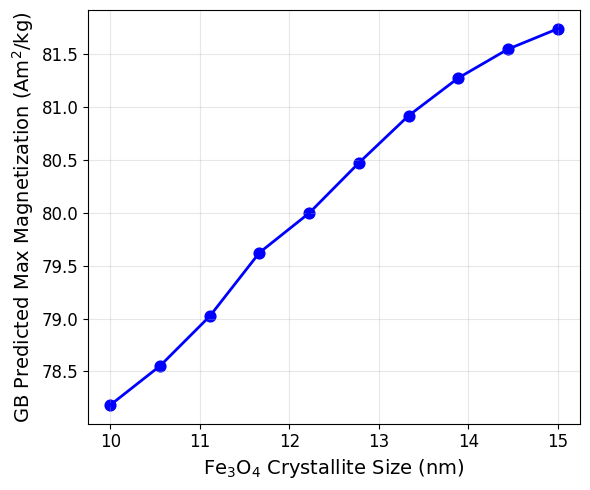

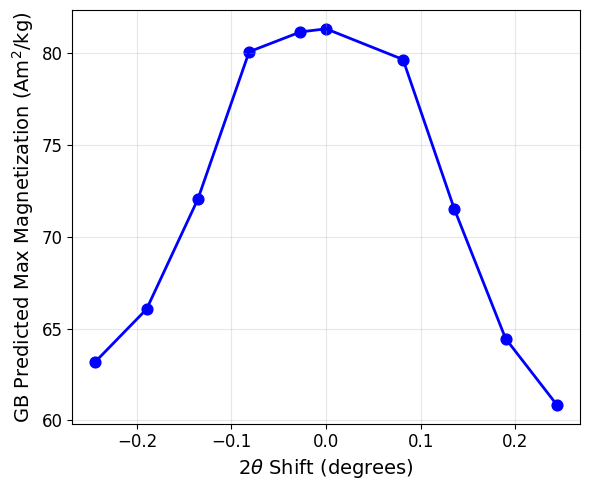

Saved: C:\Users\fabel\Documents\materials-project\notesbooks\Iron_Oxide_Model\predicted_maxM_vs_size_rf_model_fe3o4_feo_dataset_N_1000_r_42_v2.png
Saved: C:\Users\fabel\Documents\materials-project\notesbooks\Iron_Oxide_Model\predicted_maxM_vs_shift_rf_model_fe3o4_feo_dataset_N_1000_r_42_v2.png


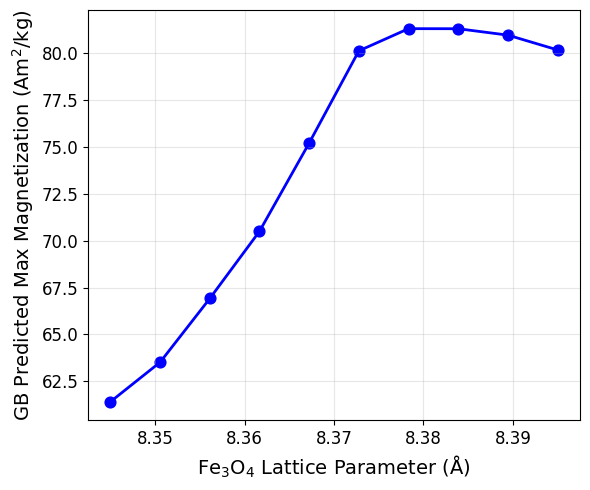

In [13]:
# Inference on simulated Fe3O4 size/shift XRD sets:
# plots crystallite size vs predicted max magnetization
# and peak shift vs predicted max magnetization

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# Inputs
# ============================================================

# Simulated XRD set generated from the previous script

SIM_DATA_NPZ = r"fe3o4_basic_size_shift_lattice_2theta_shift_fix.npz"

# Trained model to use for inference
MODEL_PKL = r"rf_model_fe3o4_feo_dataset_N_1000_r_42_v2.pkl"
# Example alternative:
#MODEL_PKL = r"gb_model_fe3o4_feo_dataset_N_1000_r_42_v3.pkl"

OUT_DIR = Path(r".")

# Plot settings
FIGSIZE = (6, 5)
AX_FONTSIZE = 14
TICK_FONTSIZE = 12
TITLE_FONTSIZE = 14
LINEWIDTH = 2
MARKERSIZE = 60
COLOR = "b"

# ============================================================
# Helper: robust model loading
# ============================================================

def load_model(path):
    import joblib, gzip, bz2, lzma, pickle as _p
    p = Path(path)

    try:
        return joblib.load(p)
    except Exception:
        pass

    try:
        with open(p, "rb") as f:
            return _p.load(f)
    except Exception:
        pass

    for opener in (gzip.open, bz2.open, lzma.open):
        try:
            with opener(p, "rb") as f:
                return _p.load(f)
        except Exception:
            continue

    with open(p, "rb") as f:
        head = f.read(8)
    raise RuntimeError(f"Could not load model {p}. Header: {head!r}")

# ============================================================
# Load simulated XRD dataset
# ============================================================

data = np.load(SIM_DATA_NPZ, allow_pickle=True)

two_theta = np.asarray(data["two_theta"], dtype=float)
xrd_size_series = np.asarray(data["xrd_size_series"], dtype=float)
xrd_shift_series = np.asarray(data["xrd_shift_series"], dtype=float)
xrd_lattice_series = np.asarray(data["xrd_lattice_series"], dtype=float)

size_values_nm = np.asarray(data["size_values_nm"], dtype=float)
shift_values_deg = np.asarray(data["shift_values_deg"], dtype=float)
fixed_shift_size_nm = float(data["fixed_shift_size_nm"])
lattice_values_A = np.asarray(data["lattice_values_A"], dtype=float)
fixed_lattice_size_nm = float(data["fixed_lattice_size_nm"])

print("Loaded simulated dataset:")
print(f"  two_theta shape          = {two_theta.shape}")
print(f"  xrd_size_series shape    = {xrd_size_series.shape}")
print(f"  xrd_shift_series shape   = {xrd_shift_series.shape}")
print(f"  xrd_lattice_series shape = {xrd_lattice_series.shape}")

# Sanity checks
assert xrd_size_series.shape[0] == size_values_nm.size, "Mismatch in size series."
assert xrd_shift_series.shape[0] == shift_values_deg.size, "Mismatch in shift series."
assert xrd_lattice_series.shape[0] == lattice_values_A.size, "Mismatch in lattice series."

# ============================================================
# Load trained model
# ============================================================

model = load_model(MODEL_PKL)
print(f"Loaded model: {MODEL_PKL}")

# ============================================================
# Predict max magnetization
# No preprocessing needed because these are already simulated
# on the same fixed grid and already normalized like training data
# ============================================================

pred_size = np.ravel(model.predict(xrd_size_series)).astype(float)
pred_shift = np.ravel(model.predict(xrd_shift_series)).astype(float)
pred_lattice = np.ravel(model.predict(xrd_lattice_series)).astype(float)

# ============================================================
# Save predictions
# ============================================================

OUT_DIR.mkdir(parents=True, exist_ok=True)

size_results = pd.DataFrame({
    "grain_size_nm": size_values_nm,
    "predicted_max_M_Am2_per_kg": pred_size
})

shift_results = pd.DataFrame({
    "peak_shift_deg": shift_values_deg,
    "grain_size_nm_fixed": fixed_shift_size_nm,
    "predicted_max_M_Am2_per_kg": pred_shift
})

lattice_results = pd.DataFrame({
    "lattice_parameter_A": lattice_values_A,
    "grain_size_nm_fixed": fixed_lattice_size_nm,
    "predicted_max_M_Am2_per_kg": pred_lattice
})

size_csv = OUT_DIR / f"predicted_maxM_vs_size_{Path(MODEL_PKL).stem}.csv"
shift_csv = OUT_DIR / f"predicted_maxM_vs_shift_{Path(MODEL_PKL).stem}.csv"
lattice_csv = OUT_DIR / f"predicted_maxM_vs_lattice_parameter_{Path(MODEL_PKL).stem}.csv"

size_results.to_csv(size_csv, index=False)
shift_results.to_csv(shift_csv, index=False)
lattice_results.to_csv(lattice_csv, index=False)

print(f"Saved: {size_csv.resolve()}")
print(f"Saved: {shift_csv.resolve()}")
print(f"Saved: {lattice_csv.resolve()}")

# ============================================================
# Plot 1: crystallite size vs predicted max magnetization
# ============================================================

plt.figure(figsize=FIGSIZE)
plt.plot(size_values_nm, pred_size, lw=LINEWIDTH, color = COLOR)
plt.scatter(size_values_nm, pred_size, s=MARKERSIZE, color = COLOR)

plt.xlabel("Fe$_3$O$_4$ Crystallite Size (nm)", fontsize=AX_FONTSIZE)
plt.ylabel("GB Predicted Max Magnetization (Am$^2$/kg)", fontsize=AX_FONTSIZE)
plt.xticks(fontsize=TICK_FONTSIZE)
plt.yticks(fontsize=TICK_FONTSIZE)
plt.grid(alpha=0.3)
plt.tight_layout()

plot1_path = OUT_DIR / f"predicted_maxM_vs_size_{Path(MODEL_PKL).stem}.png"
plt.savefig(plot1_path, dpi=200)
plt.show()

# ============================================================
# Plot 2: peak shift vs predicted max magnetization
# ============================================================

plt.figure(figsize=FIGSIZE)
plt.plot(shift_values_deg, pred_shift, lw=LINEWIDTH, color = COLOR)
plt.scatter(shift_values_deg, pred_shift, s=MARKERSIZE, color = COLOR)

plt.xlabel(r"2$\theta$ Shift (degrees)", fontsize=AX_FONTSIZE)
plt.ylabel("GB Predicted Max Magnetization (Am$^2$/kg)", fontsize=AX_FONTSIZE)
plt.xticks(fontsize=TICK_FONTSIZE)
plt.yticks(fontsize=TICK_FONTSIZE)
plt.grid(alpha=0.3)
plt.tight_layout()

plot2_path = OUT_DIR / f"predicted_maxM_vs_shift_{Path(MODEL_PKL).stem}.png"
plt.savefig(plot2_path, dpi=200)
plt.show()

print(f"Saved: {plot1_path.resolve()}")
print(f"Saved: {plot2_path.resolve()}")

# ============================================================
# Plot 3: lattice parameter vs predicted max magnetization
# ============================================================

plt.figure(figsize=FIGSIZE)
plt.plot(lattice_values_A, pred_lattice, lw=LINEWIDTH, color = COLOR)
plt.scatter(lattice_values_A, pred_lattice, s=MARKERSIZE, color = COLOR)

plt.xlabel("Fe$_3$O$_4$ Lattice Parameter (Å)", fontsize=AX_FONTSIZE)
plt.ylabel("GB Predicted Max Magnetization (Am$^2$/kg)", fontsize=AX_FONTSIZE)
plt.xticks(fontsize=TICK_FONTSIZE)
plt.yticks(fontsize=TICK_FONTSIZE)
plt.grid(alpha=0.3)
plt.tight_layout()

plot3_path = OUT_DIR / f"predicted_maxM_vs_lattice_parameter_{Path(MODEL_PKL).stem}.png"
plt.savefig(plot3_path, dpi=200)
plt.show()

Saved raw shifted experimental CSV: C:\Users\fabel\Documents\materials-project\notesbooks\Iron_Oxide_Model\experimanta_data\XRD_M-B_datasets_manuscript_names\E4_XRD_bg_sub_raw_2theta_shift_p0p202deg.csv
  Shift applied to column: 24.99
  Intensity column left unchanged: 0
  Applied shift: +0.2016 degrees 2theta
shift = -0.2440 deg -> predicted max M = 46.941932 Am^2/kg
shift = -0.2196 deg -> predicted max M = 47.699813 Am^2/kg
shift = -0.1952 deg -> predicted max M = 49.604691 Am^2/kg
shift = -0.1708 deg -> predicted max M = 52.033621 Am^2/kg
shift = -0.1464 deg -> predicted max M = 53.529150 Am^2/kg
shift = -0.1220 deg -> predicted max M = 55.092483 Am^2/kg
shift = -0.0976 deg -> predicted max M = 56.392620 Am^2/kg
shift = -0.0732 deg -> predicted max M = 58.581391 Am^2/kg
shift = -0.0488 deg -> predicted max M = 60.071401 Am^2/kg
shift = -0.0244 deg -> predicted max M = 61.138904 Am^2/kg
shift = +0.0000 deg -> predicted max M = 63.123374 Am^2/kg
shift = +0.0244 deg -> predicted max M

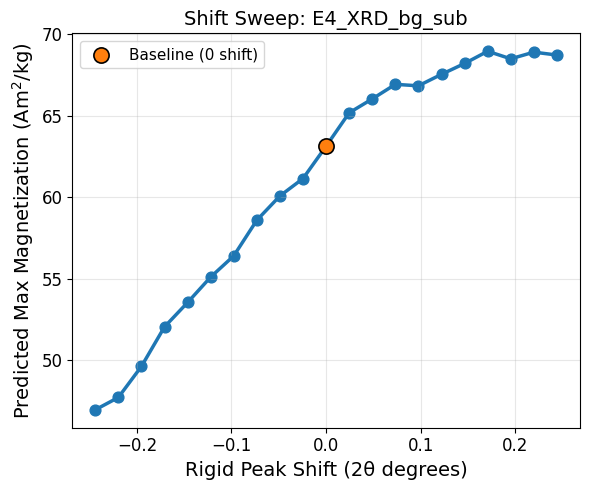

Saved plot: C:\Users\fabel\Documents\materials-project\notesbooks\Iron_Oxide_Model\experimanta_data\XRD_M-B_datasets_manuscript_names\E4_XRD_bg_sub_shift_vs_predicted_maxM_rf_model_fe3o4_feo_dataset_N_1000_r_42_v2.png


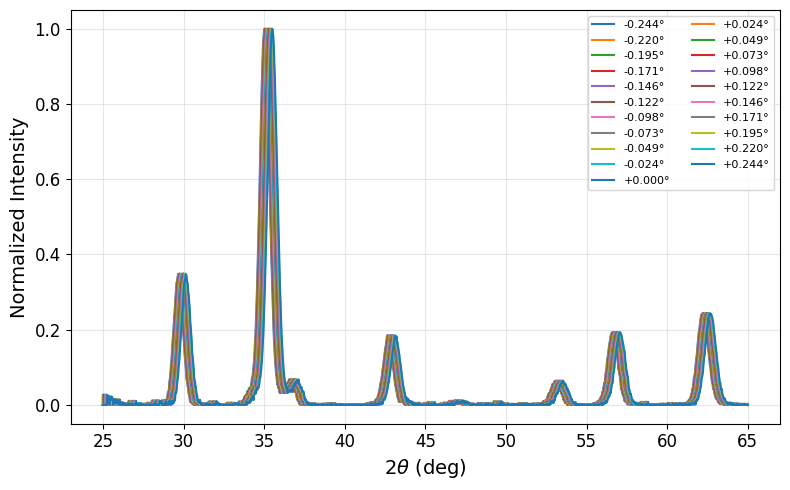

Saved plot: C:\Users\fabel\Documents\materials-project\notesbooks\Iron_Oxide_Model\experimanta_data\XRD_M-B_datasets_manuscript_names\E4_XRD_bg_sub_shifted_patterns_rf_model_fe3o4_feo_dataset_N_1000_r_42_v2.png


In [18]:
# ============================================================
# Experimental XRD shift sweep:
# preprocess one experimental XRD csv, apply rigid 2theta shifts,
# predict max magnetization, and plot shift vs prediction
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# Inputs
# ============================================================

# ============================================================
# save one raw experimentally shifted CSV
# ============================================================

SAVE_SINGLE_SHIFTED_CSV = True

# Sign convention:
# shifted_2theta = original_2theta + SINGLE_SHIFT_DEG
# Example: -0.20 moves all peaks to lower 2theta by 0.20 degrees.
#SINGLE_SHIFT_DEG = 0.21038 # this is original, same after 2theta correction
#SINGLE_SHIFT_DEG = 0.2016418 # 

#SINGLE_SHIFT_DEG = 0.2104 # test with corrected gfrm grid


SINGLE_SHIFT_DEG = 0.201642 # from Bruker processed fits and bg sub


# Experimental XRD file: define directory and filename separately
XRD_DIR  = Path(r"C:\Users\fabel\Documents\materials-project\notesbooks\Iron_Oxide_Model\experimanta_data\XRD_M-B_datasets_manuscript_names")
XRD_FILE = r"E4_XRD_bg_sub.csv"

# Trained model and training-grid source
MODEL_PKL  = r"rf_model_fe3o4_feo_dataset_N_1000_r_42_v2.pkl"
# MODEL_PKL = r"gb_model_fe3o4_feo_dataset_N_1000_r_42_v3.pkl"
GRID_SOURCE = r"fe3o4_feo_dataset_N_1000_r_42.npz"   # contains two_theta grid from training

# Output directory
OUT_DIR = Path(r"C:\Users\fabel\Documents\materials-project\notesbooks\Iron_Oxide_Model\experimanta_data\XRD_M-B_datasets_manuscript_names")

# Shift sweep settings
SHIFT_MIN_DEG = -0.244
SHIFT_MAX_DEG =  0.244
N_SHIFTS = 21   # includes baseline 0.0 if odd and symmetric
# Example: 21 -> [-0.10, -0.09, ..., 0.00, ..., +0.10]

# XRD processing params
CLIP_NONNEG  = True
CROP_TO_GRID = True

# Plot settings
FIGSIZE = (6, 5)
AX_FONTSIZE = 14
TICK_FONTSIZE = 12
TITLE_FONTSIZE = 14
LINEWIDTH = 2.5
MARKERSIZE = 60

# Optional: overlay shifted/resampled patterns used by the model
PLOT_SHIFTED_PATTERNS = True

# ============================================================
# Helper functions
# ============================================================

def load_two_theta_grid(grid_source_path):
    p = Path(grid_source_path)
    if p.suffix.lower() == ".npz":
        data = np.load(p, allow_pickle=True)
        if "two_theta" not in data:
            raise KeyError("NPZ missing 'two_theta'.")
        return np.asarray(data["two_theta"]).astype(float)
    elif p.suffix.lower() == ".npy":
        return np.load(p).astype(float)
    else:
        raise ValueError("GRID_SOURCE must be .npz (with 'two_theta') or .npy of the training grid.")

def smart_read_xrd_csv(path):
    df = pd.read_csv(path)
    cols = {c.lower(): c for c in df.columns}

    th_keys = [k for k in cols if k in ["2theta", "two_theta", "angle", "2θ", "theta"]]
    I_keys  = [k for k in cols if k in ["intensity", "counts", "i", "y"]]

    if th_keys and I_keys:
        x = df[cols[th_keys[0]]].to_numpy(dtype=float)
        y = df[cols[I_keys[0]]].to_numpy(dtype=float)
    else:
        x = df.iloc[:, 0].to_numpy(dtype=float)
        y = df.iloc[:, 1].to_numpy(dtype=float)

    m = np.isfinite(x) & np.isfinite(y)
    x, y = x[m], y[m]
    order = np.argsort(x)
    return x[order], y[order]

def resample_to_grid(x, y, grid, fill_value=0.0):
    y_grid = np.interp(grid, x, y, left=np.nan, right=np.nan)
    y_grid[grid < x.min()] = fill_value
    y_grid[grid > x.max()] = fill_value
    return np.nan_to_num(y_grid, nan=fill_value, posinf=fill_value, neginf=fill_value)

def normalize_max(y, eps=1e-12):
    y = np.asarray(y, float)
    m = np.nanmax(y)
    return y / (m if m > eps else eps)

def load_model(path):
    import joblib, gzip, bz2, lzma, pickle as _p
    p = Path(path)

    try:
        return joblib.load(p)
    except Exception:
        pass

    try:
        with open(p, "rb") as f:
            return _p.load(f)
    except Exception:
        pass

    for opener in (gzip.open, bz2.open, lzma.open):
        try:
            with opener(p, "rb") as f:
                return _p.load(f)
        except Exception:
            continue

    with open(p, "rb") as f:
        head = f.read(8)
    raise RuntimeError(f"Could not load model {p}. Header: {head!r}")


def find_xrd_columns(df):
    """
    Identify 2theta and intensity columns.

    If standard names are not found, defaults to the first two columns.
    """
    col_lookup = {str(c).strip().lower(): c for c in df.columns}

    theta_aliases = ["2theta", "two_theta", "angle", "2θ", "theta"]
    intensity_aliases = ["intensity", "counts", "i", "y"]

    theta_col = None
    intensity_col = None

    for key in theta_aliases:
        if key in col_lookup:
            theta_col = col_lookup[key]
            break

    for key in intensity_aliases:
        if key in col_lookup:
            intensity_col = col_lookup[key]
            break

    if theta_col is None:
        theta_col = df.columns[0]

    if intensity_col is None:
        intensity_col = df.columns[1]

    return theta_col, intensity_col


def format_shift_for_filename(shift_deg):
    """
    Convert shift value to a filename-safe string.
    Example:
        -0.20 -> m0p200
        +0.15 -> p0p150
    """
    sign = "p" if shift_deg >= 0 else "m"
    val = abs(float(shift_deg))
    return sign + f"{val:.3f}".replace(".", "p")


def save_raw_shifted_experimental_csv(xrd_path, out_dir, shift_deg):
    """
    Save a new experimental XRD CSV with only the 2theta column shifted.

    This does not crop, clip, normalize, interpolate, resample, sort, or alter
    the intensity values. It simply applies:

        shifted_2theta = original_2theta + shift_deg
    """
    df_raw = pd.read_csv(xrd_path)
    theta_col, intensity_col = find_xrd_columns(df_raw)

    df_shifted = df_raw.copy()
    df_shifted[theta_col] = pd.to_numeric(df_shifted[theta_col], errors="coerce") + float(shift_deg)

    shift_tag = format_shift_for_filename(shift_deg)

    out_path = (
        Path(out_dir)
        / f"{Path(xrd_path).stem}_raw_2theta_shift_{shift_tag}deg.csv"
    )

    df_shifted.to_csv(out_path, index=False)

    print(f"Saved raw shifted experimental CSV: {out_path.resolve()}")
    print(f"  Shift applied to column: {theta_col}")
    print(f"  Intensity column left unchanged: {intensity_col}")
    print(f"  Applied shift: {shift_deg:+.4f} degrees 2theta")

    return out_path

# ============================================================
# Experimental XRD preprocessing + rigid shift
# ============================================================

def preprocess_experimental_xrd_with_shift(
    x_path,
    grid,
    shift_deg=0.0,
    *,
    clip_nonneg=CLIP_NONNEG,
    crop_to_grid=CROP_TO_GRID
):
    """
    Read one experimental XRD csv, apply the same simple preprocessing
    as the earlier inference workflow, then apply a rigid 2theta shift
    before interpolation onto the training grid.

    Returns:
        x_use         : cropped raw 2theta values (unshifted)
        y_norm        : normalized raw intensity on raw axis
        x_shifted     : shifted raw 2theta values
        y_grid        : shifted + resampled + renormalized XRD on training grid
    """
    x_raw, y_raw = smart_read_xrd_csv(x_path)

    grid_min, grid_max = float(np.min(grid)), float(np.max(grid))

    if crop_to_grid:
        # keep enough margin so shifted curves still interpolate sensibly
        pad = max(abs(SHIFT_MIN_DEG), abs(SHIFT_MAX_DEG)) + 0.02
        m = (x_raw >= (grid_min - pad)) & (x_raw <= (grid_max + pad))
        x_use, y_use = x_raw[m], y_raw[m]
        if x_use.size < 7:
            raise ValueError(f"{x_path}: too few points in or near training grid range.")
    else:
        x_use, y_use = x_raw, y_raw

    if clip_nonneg:
        y_use = np.clip(y_use, 0, None)

    # normalize on raw axis first
    y_norm = normalize_max(y_use)

    # apply rigid shift to 2theta axis
    x_shifted = x_use + float(shift_deg)

    # resample to training grid
    y_grid = resample_to_grid(x_shifted, y_norm, grid, fill_value=0.0)

    # renormalize after interpolation
    y_grid = normalize_max(y_grid)

    return x_use, y_norm, x_shifted, y_grid

# ============================================================
# Main
# ============================================================

OUT_DIR.mkdir(parents=True, exist_ok=True)

xrd_path = XRD_DIR / XRD_FILE
if not xrd_path.exists():
    raise FileNotFoundError(f"Missing XRD file: {xrd_path}")

if SAVE_SINGLE_SHIFTED_CSV:
    shifted_csv_path = save_raw_shifted_experimental_csv(
        xrd_path=xrd_path,
        out_dir=OUT_DIR,
        shift_deg=SINGLE_SHIFT_DEG
    )

two_theta_grid = load_two_theta_grid(GRID_SOURCE)
model = load_model(MODEL_PKL)

shift_values_deg = np.linspace(SHIFT_MIN_DEG, SHIFT_MAX_DEG, N_SHIFTS)

# force one exact baseline sample at 0 if symmetric/near-symmetric
shift_values_deg[np.argmin(np.abs(shift_values_deg))] = 0.0

rows = []
patterns_for_plot = []

for shift_deg in shift_values_deg:
    x_use, y_norm, x_shifted, y_grid = preprocess_experimental_xrd_with_shift(
        xrd_path,
        two_theta_grid,
        shift_deg=shift_deg
    )

    X_feat = y_grid.reshape(1, -1)
    pred_max_M = float(np.ravel(model.predict(X_feat))[0])

    rows.append({
        "xrd_file": str(xrd_path),
        "shift_deg": float(shift_deg),
        "predicted_max_M_Am2_per_kg": pred_max_M
    })

    patterns_for_plot.append((shift_deg, y_grid.copy()))

    print(f"shift = {shift_deg:+.4f} deg -> predicted max M = {pred_max_M:.6f} Am^2/kg")

results = pd.DataFrame(rows)

# Save results table
results_csv = OUT_DIR / f"{Path(XRD_FILE).stem}_shift_sweep_{Path(MODEL_PKL).stem}.csv"
results.to_csv(results_csv, index=False)
print(f"\nSaved results: {results_csv.resolve()}")

# Baseline prediction at shift = 0
idx0 = int(np.argmin(np.abs(results["shift_deg"].to_numpy())))
baseline_pred = float(results.iloc[idx0]["predicted_max_M_Am2_per_kg"])
print(f"Baseline (0 shift) predicted max M = {baseline_pred:.6f} Am^2/kg")

# ============================================================
# Plot 1: shift vs predicted max magnetization
# ============================================================

plt.figure(figsize=FIGSIZE)
plt.plot(results["shift_deg"], results["predicted_max_M_Am2_per_kg"], lw=LINEWIDTH)
plt.scatter(results["shift_deg"], results["predicted_max_M_Am2_per_kg"], s=MARKERSIZE)

# highlight baseline 0 shift point
plt.scatter(
    results.iloc[idx0]["shift_deg"],
    results.iloc[idx0]["predicted_max_M_Am2_per_kg"],
    s=120,
    marker="o",
    edgecolors="k",
    linewidths=1.2,
    zorder=5,
    label="Baseline (0 shift)"
)

plt.xlabel("Rigid Peak Shift (2θ degrees)", fontsize=AX_FONTSIZE)
plt.ylabel("Predicted Max Magnetization (Am$^2$/kg)", fontsize=AX_FONTSIZE)
plt.title(f"Shift Sweep: {Path(XRD_FILE).stem}", fontsize=TITLE_FONTSIZE)
plt.xticks(fontsize=TICK_FONTSIZE)
plt.yticks(fontsize=TICK_FONTSIZE)
plt.grid(alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()

plot1_path = OUT_DIR / f"{Path(XRD_FILE).stem}_shift_vs_predicted_maxM_{Path(MODEL_PKL).stem}.png"
plt.savefig(plot1_path, dpi=200)
plt.show()

print(f"Saved plot: {plot1_path.resolve()}")

# ============================================================
# Plot 2 (optional): shifted/resampled XRD patterns used by model
# ============================================================

if PLOT_SHIFTED_PATTERNS:
    plt.figure(figsize=(8, 5))
    for shift_deg, y_grid in patterns_for_plot:
        plt.plot(two_theta_grid, y_grid, lw=1.5, label=f"{shift_deg:+.3f}°")

    plt.xlabel(r"2$\theta$ (deg)", fontsize=AX_FONTSIZE)
    plt.ylabel("Normalized Intensity", fontsize=AX_FONTSIZE)
    #plt.title(f"Shifted / Resampled XRD Patterns: {Path(XRD_FILE).stem}", fontsize=TITLE_FONTSIZE)
    plt.xticks(fontsize=TICK_FONTSIZE)
    plt.yticks(fontsize=TICK_FONTSIZE)
    plt.grid(alpha=0.3)
    plt.legend(fontsize=8, ncol=2)
    plt.tight_layout()

    plot2_path = OUT_DIR / f"{Path(XRD_FILE).stem}_shifted_patterns_{Path(MODEL_PKL).stem}.png"
    plt.savefig(plot2_path, dpi=200)
    plt.show()

    print(f"Saved plot: {plot2_path.resolve()}")